# Nitrate spatial distribution in 2011 and 2018

This notebook plots the spatial distributions of nitrate before/after storms in 2011 and 2018.

## Data Inspection

To confirm the source of the source and the formats of the nitrate data, the following section checks the NC files.

In [ ]:
# Data inspection

# import

import xarray as xr
import numpy as np

# file dir
# Example path: /results2/SalishSea/nowcast-green.201905/01apr18/SalishSea_1h_20180401_20180401_ptrc_T.nc

BASE_DIR = '/results2/SalishSea/nowcast-green.201905/'
Date_DIR = '01apr18/'
fname = 'SalishSea_1h_20180401_20180401_ptrc_T.nc'



DIR_full = BASE_DIR + Date_DIR + fname

ds = xr.open_dataset(DIR_full)

print(ds)

VAR_NITRATE = 'nitrate'

<xarray.Dataset> Size: 15GB
Dimensions:                       (y: 898, x: 398, nvertex: 4, deptht: 40,
                                   axis_nbounds: 2, time_counter: 24)
Coordinates:
    nav_lat                       (y, x) float32 1MB ...
    nav_lon                       (y, x) float32 1MB ...
  * deptht                        (deptht) float32 160B 0.5 1.5 ... 414.5 441.5
    time_centered                 (time_counter) datetime64[ns] 192B ...
  * time_counter                  (time_counter) datetime64[ns] 192B 2018-04-...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables: (12/17)
    bounds_lon                    (y, x, nvertex) float32 6MB ...
    bounds_lat                    (y, x, nvertex) float32 6MB ...
    area                          (y, x) float32 1MB ...
    deptht_bounds                 (deptht, axis_nbounds) float32 320B ...
    nitrate                       (time_counter, deptht, y, x) float32 1GB ...
    time_centered_bounds          (time_

In [7]:
print(ds['nitrate'].attrs.get('units', 'No units found'))

mmol m-3


Hourly nitrate data can be found in /results2/SalishSea/nowcast-green.201905/, with 'ptrc'. The unit is mmol m-3.

## Visualization

The following section visualizes the nitrate distribution, based on codes from D&F_Section.



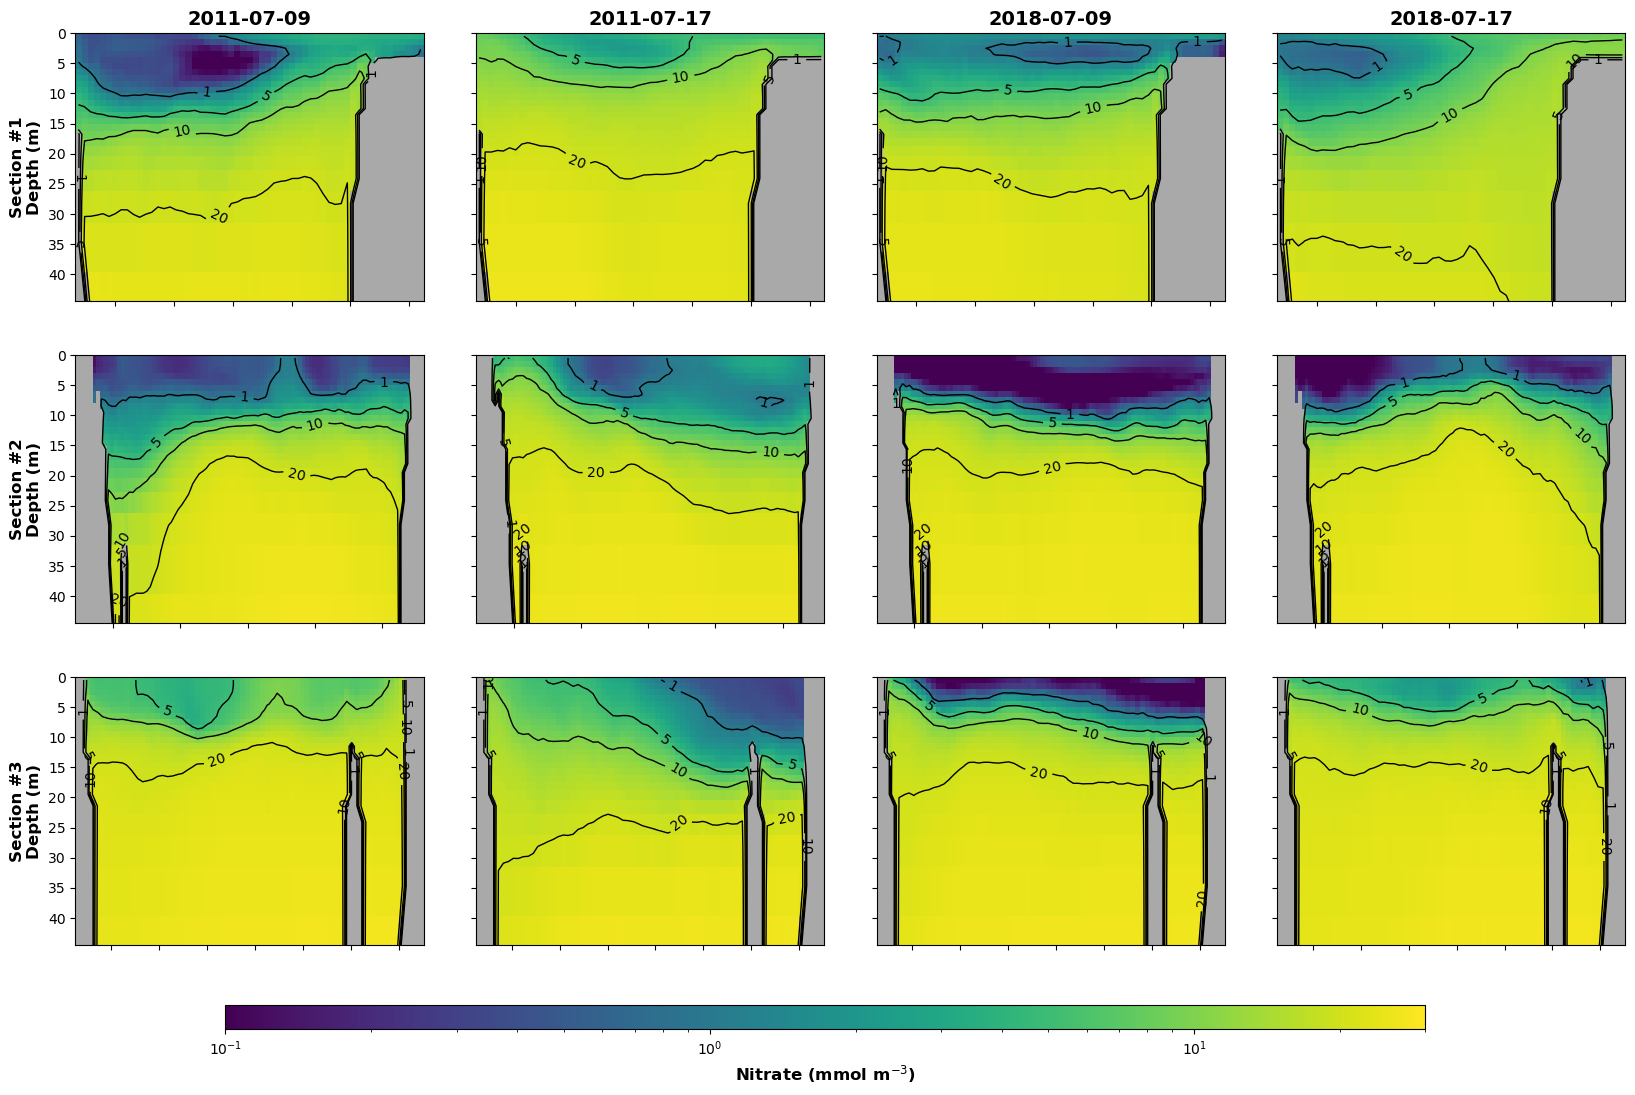

In [ ]:
# 2011 and 2018 nitrate section plot

import netCDF4 as nc
import numpy as np
import datetime
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

# dir
BASE_DIR = '/results2/SalishSea/nowcast-green.201905/'
FNAME_HEAD = 'SalishSea_1d_' 
FNAME_TAIL = '_ptrc_T.nc'

# section
SECTIONS = ['Point_1', 'Point_2', 'Point_3']
TARGETS_DEFINITIONS = {
    'Point_1': {'value': (49.0, -123.25), 'label': 'Section #1'},
    'Point_2': {'value': (49.3, -124.0),  'label': 'Section #2'},
    'Point_3': {'value': (49.9, -124.8),  'label': 'Section #3'},
}

SECTION_CONFIG = {
    'Point_1': {'left_offset': 35, 'right_offset': 22},
    'Point_2': {'left_offset': 30, 'right_offset': 70},
    'Point_3': {'left_offset': 45, 'right_offset': 25},
}

DEPTH_LIMIT = 50

# 2011 vs 2018
COLUMNS_INFO = [
    {'date': datetime.date(2011, 7, 9),  'title': '2011-07-09'},
    {'date': datetime.date(2011, 7, 17), 'title': '2011-07-17'},
    {'date': datetime.date(2018, 7, 9),  'title': '2018-07-09'},
    {'date': datetime.date(2018, 7, 17), 'title': '2018-07-17'},
]

# functions

def find_nearest_indices_2d(lon_2d, lat_2d, target_lon, target_lat):
    dist_sq = (lon_2d - target_lon)**2 + (lat_2d - target_lat)**2
    return np.unravel_index(dist_sq.argmin(), lon_2d.shape)

def load_nitrate_data(date_obj, y_idx, x_idx, config, lon_2d):
    file_path = os.path.join(
        BASE_DIR,
        date_obj.strftime('%d%b%y').lower(),
        f"{FNAME_HEAD}{date_obj.strftime('%Y%m%d')}_{date_obj.strftime('%Y%m%d')}{FNAME_TAIL}"
    )
    
    if not os.path.exists(file_path): 
        print(f"Warning: File not found -> {file_path}")
        return None
    
    with nc.Dataset(file_path, 'r') as ncfile:
        z_var = ncfile.variables['deptht'][:]
        z_idx_limit = np.abs(z_var - DEPTH_LIMIT).argmin()
        
        x_start = max(0, x_idx - config['left_offset'])
        x_end = min(lon_2d.shape[1], x_idx + config['right_offset'])
        x_slice = slice(x_start, x_end)
        
        nitrate = ncfile.variables['nitrate'][0, :z_idx_limit+1, y_idx, x_slice]
        lon_sec = lon_2d[y_idx, x_slice]
        
        return nitrate, lon_sec, z_var[:z_idx_limit+1]

def plot_single_panel(ax, data, lon, depths):
    ax.set_facecolor('darkgray') 
    
    # nitrate
    cmap = 'viridis'
    vmin, vmax = 0.1, 30
    contour_levels = [1, 5, 10, 20]

    data_masked = np.ma.masked_less_equal(data, 0)
    X, Z = np.meshgrid(lon, depths)
    
    cf = ax.pcolormesh(X, Z, data_masked, 
                       norm=LogNorm(vmin=vmin, vmax=vmax),
                       cmap=cmap, shading='auto')
    
    cs = ax.contour(X, Z, data, levels=contour_levels,
                    colors='black', linewidths=1, alpha=0.7)
    plt.setp(CS.collections, 
         path_effects=[pe.withStroke(linewidth=1.2, foreground="white")])
    ax.clabel(cs, fontsize=10)
    
    ax.set_ylim(depths.max(), 0)
    
    return cf

# main

def main():
    sample_coord_file = os.path.join(
        BASE_DIR,
        '09jun11/SalishSea_1d_20110609_20110609_ptrc_T.nc'
    )
    
    with nc.Dataset(sample_coord_file, 'r') as nf:
        lon_2d = nf.variables['nav_lon'][:]
        lat_2d = nf.variables['nav_lat'][:]

    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
    plt.subplots_adjust(hspace=0.2, wspace=0.15, bottom=0.12)

    cf_ref = None

    for row_idx, p_id in enumerate(SECTIONS):
        p_def = TARGETS_DEFINITIONS[p_id]
        y_idx, x_idx = find_nearest_indices_2d(
            lon_2d, lat_2d,
            p_def['value'][1], p_def['value'][0]
        )

        for col_idx, col_info in enumerate(COLUMNS_INFO):
            ax = axes[row_idx, col_idx]

            res = load_nitrate_data(
                col_info['date'],
                y_idx, x_idx,
                SECTION_CONFIG[p_id],
                lon_2d
            )

            if res is None:
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center')
                continue

            nitrate, lon_s, depth_s = res
            cf = plot_single_panel(ax, nitrate, lon_s, depth_s)
            cf_ref = cf

            # 标题
            if row_idx == 0:
                ax.set_title(col_info['title'], fontsize=14, fontweight='bold')

            # 左侧
            if col_idx == 0:
                ax.set_ylabel(f"{p_def['label']}\nDepth (m)", fontsize=12, fontweight='bold')

            
            ax.set_xticklabels([])

    # unified colorbar
    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
    cbar = fig.colorbar(cf_ref, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Nitrate (mmol m$^{-3}$)', fontsize=12, fontweight='bold')

    plt.show()

if __name__ == '__main__':
    main()